In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from imblearn.over_sampling import RandomOverSampler
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

In [2]:
df =pd.read_csv("data.csv")
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


EDA

In [3]:
df.shape

(381109, 12)

In [4]:
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [6]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


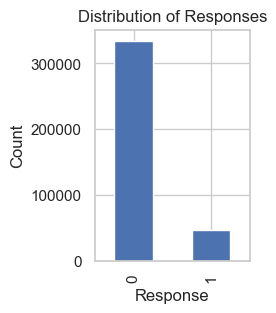

In [7]:
value_count = df['Response'].value_counts()
plt.figure(figsize=(2,3))

#Create the bar plot
value_count.plot(kind='bar')

#Customize the plot
plt.xlabel('Response')
plt.ylabel('Count')
plt.title('Distribution of Responses')

#Show the plot
plt.show()

<Axes: >

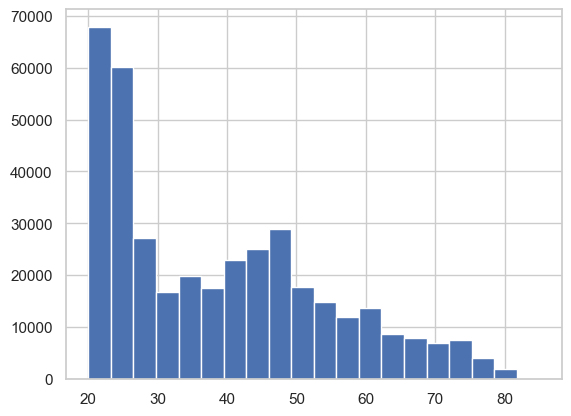

In [8]:
df['Age'].hist(bins=20)

Data Preprocessing

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [10]:
num_feat =["Age", "Vintage"]
cat_feat = ["Gender","Driving_License","Region_Code", "Previously_Insured","Vehicle_Age","Vehicle_Damage","Annual_Premium","Policy_Sales_Channel","Vintage","Response"]

In [11]:
#mapping 'Gender' col to(0,1) value
df['Gender'] = df['Gender'].map({'Female':0, 'Male':1}).astype(int)
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,1,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,1,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,1,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,1,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,0,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [12]:
for col in df.columns:
    print(f"{col} >> {df[col].dtype}")

id >> int64
Gender >> int32
Age >> int64
Driving_License >> int64
Region_Code >> float64
Previously_Insured >> int64
Vehicle_Age >> object
Vehicle_Damage >> object
Annual_Premium >> float64
Policy_Sales_Channel >> float64
Vintage >> int64
Response >> int64


In [13]:
df=pd.get_dummies(df, drop_first=True)
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,1,1,44,1,28.0,0,40454.0,26.0,217,1,False,True,True
1,2,1,76,1,3.0,0,33536.0,26.0,183,0,False,False,False
2,3,1,47,1,28.0,0,38294.0,26.0,27,1,False,True,True
3,4,1,21,1,11.0,1,28619.0,152.0,203,0,True,False,False
4,5,0,29,1,41.0,1,27496.0,152.0,39,0,True,False,False


In [14]:
for col in df.columns:
    print(f"{col} >> {df[col].dtype}")

id >> int64
Gender >> int32
Age >> int64
Driving_License >> int64
Region_Code >> float64
Previously_Insured >> int64
Annual_Premium >> float64
Policy_Sales_Channel >> float64
Vintage >> int64
Response >> int64
Vehicle_Age_< 1 Year >> bool
Vehicle_Age_> 2 Years >> bool
Vehicle_Damage_Yes >> bool


In [15]:
cat_feat = [col for col in cat_feat if col in df.columns]

In [16]:
df =df.rename(columns={"Vehicle_Age_< 1 Year":"Vehicle_Age_It_1_Year", "Vehicle_Age_> 2 Years":"Vehicle_Age_gt_2_year"})
df["Vehicle_Age_It_1_Year"] =df["Vehicle_Age_It_1_Year"].astype('int')
df["Vehicle_Age_gt_2_year"] =df["Vehicle_Age_gt_2_year"].astype('int')
df["Vehicle_Damage_Yes"] = df["Vehicle_Damage_Yes"].astype('int')

for column in cat_feat:
    df[column] = df[column].astype('str')


In [17]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MaxAbsScaler, RobustScaler
ss = StandardScaler()
df[num_feat] = ss.fit_transform(df[num_feat])

mm=MaxAbsScaler()
df[['Annual_Premium']] = mm.fit_transform(df[['Annual_Premium']])

#also dropping id col now
df=df.drop('id', axis=1)

In [18]:
from sklearn.model_selection import train_test_split

train_target = df['Response']
train = df.drop(['Response'], axis=1)
x_train, x_test, y_train, y_test = train_test_split(train, train_target, random_state=0)

In [19]:
train_target

0         1
1         0
2         1
3         0
4         0
         ..
381104    0
381105    0
381106    0
381107    0
381108    0
Name: Response, Length: 381109, dtype: object

Model Trainer - Random Forest Classifier

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameters
random_search = {
    'criterion': ['entropy', 'gini'],
    'max_depth': [2, 3, 4, 5, 6, 7, 10],
    'min_samples_split': [4, 6, 8],
    'min_samples_leaf': [5, 7, 10],
    'n_estimators': [100, 200, 300]
}

x_small = x_train.sample(n=20000, random_state=42)
y_small = y_train.loc[x_small.index]

model = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=random_search,
    n_iter=5,
    cv=3,
    n_jobs=-1,
    verbose=3,
    random_state=42,
    scoring='accuracy'
)

model.fit(x_small, y_small)

# Access everything immediately after fit
best_params = model.best_params_
best_score = model.best_score_
best_estimator = model.best_estimator_

print("Best Parameters:", best_params)
print("Best CV Score:", best_score)
print("Best Estimator:", best_estimator)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_depth': 5, 'criterion': 'gini'}
Best CV Score: 0.8747000018735936
Best Estimator: RandomForestClassifier(max_depth=5, min_samples_leaf=7, min_samples_split=8,
                       n_estimators=300, random_state=42)


In [21]:
import pickle
filename = 'rf_model.pkl'
pickle.dump(model, open(filename, 'wb'))

In [22]:
import pickle

with open(filename, 'rb') as file:
    rf_load = pickle.load(file)

In [23]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93     83603
           1       0.00      0.00      0.00     11675

    accuracy                           0.88     95278
   macro avg       0.44      0.50      0.47     95278
weighted avg       0.77      0.88      0.82     95278

